# Machine Learning-Based Prediction of Superconducting Critical Temperature Using Material Descriptors

### A Computational Physics Regression Project

**Author:** Kaveri Yadav

## Project Goal

The objective of this project is to develop machine learning regression models for predicting the superconducting critical temperature (Tc) from material descriptors. Multiple models are compared using standard regression metrics, and SHAP (SHapley Additive exPlanations) is employed to interpret feature importance and improve model transparency.

## Workflow

1. Import Libraries
2. Load Dataset
3. Dataset Overview
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Model Training
   - Linear Regression
   - Random Forest Regression
   - Hyperparameter Optimization
   - XGBoost Regression
7. Model Evaluation
8. Feature Importance Analysis
9. Model Comparison
10. Model Explainability (SHAP)
11. Conclusions

### 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, machine learning model development, evaluation, and explainable AI.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))
print(sys.path[-1]) 

from src.evaluation import evaluate_model, print_results

from src.data_preprocessing import (
    load_data,
    split_features_target,
    split_data
)

from src.models import (
    train_linear_regression,
    train_random_forest,
    train_xgboost
)

from src.explainability import (
    compute_shap_values,
    plot_shap_summary,
    plot_feature_importance
)


d:\Projects\Predict-Physical-Quantities-Using-Machine-Learning


### 2. Load Dataset

The superconductivity dataset is loaded into a pandas DataFrame for subsequent preprocessing, analysis, and model training.

In [4]:
df = load_data(
    r"D:\Projects\Predict-Physical-Quantities-Using-Machine-Learning\data\raw\train.csv"
)

#### 3. Dataset Overview

#### The first few rows of the dataset are displayed to understand its structure, feature names, and sample values.

In [5]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


#### Dataset Dimensions

The dimensions of the dataset are examined to determine the number of observations and features available for model development.

In [6]:
df.shape

(21263, 82)

In [7]:
df.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

#### Dataset Information

The dataset structure is inspected to verify data types, non-null values, and overall data completeness.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

#### Summary Statistics

Descriptive statistics are computed to summarize the distribution of numerical features, including their mean, standard deviation, minimum, maximum, and quartiles.

In [9]:
df.describe()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
count,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,...,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000,21263.000000
mean,4.115224,87.557631,72.988310,71.290627,58.539916,1.165608,1.063884,115.601251,33.225218,44.391893,...,3.153127,3.056536,3.055885,1.295682,1.052841,2.041010,1.483007,0.839342,0.673987,34.421219
std,1.439295,29.676497,33.490406,31.030272,36.651067,0.364930,0.401423,54.626887,26.967752,20.035430,...,1.191249,1.046257,1.174815,0.393155,0.380291,1.242345,0.978176,0.484676,0.455580,34.254362
min,1.000000,6.941000,6.423452,5.320573,1.960849,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000210
25%,3.000000,72.458076,52.143839,58.041225,35.248990,0.966676,0.775363,78.512902,16.824174,32.890369,...,2.116732,2.279705,2.091251,1.060857,0.775678,1.000000,0.921454,0.451754,0.306892,5.365000
50%,4.000000,84.922750,60.696571,66.361592,39.918385,1.199541,1.146783,122.906070,26.636008,45.123500,...,2.618182,2.615321,2.434057,1.368922,1.166532,2.000000,1.063077,0.800000,0.500000,20.000000
75%,5.000000,100.404410,86.103540,78.116681,73.113234,1.444537,1.359418,154.119320,38.356908,59.322812,...,4.026201,3.727919,3.914868,1.589027,1.330801,3.000000,1.918400,1.200000,1.020436,63.000000
max,9.000000,208.980400,208.980400,208.980400,208.980400,1.983797,1.958203,207.972460,205.589910,101.019700,...,7.000000,7.000000,7.000000,2.141963,1.949739,6.000000,6.992200,3.000000,3.000000,185.000000


### 4. Exploratory Data Analysis (EDA)

In [10]:
print("Rows and Columns:", df.shape)

Rows and Columns: (21263, 82)


In [11]:
df.isnull().sum()

number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64

In [12]:
list(df.columns)

['number_of_elements',
 'mean_atomic_mass',
 'wtd_mean_atomic_mass',
 'gmean_atomic_mass',
 'wtd_gmean_atomic_mass',
 'entropy_atomic_mass',
 'wtd_entropy_atomic_mass',
 'range_atomic_mass',
 'wtd_range_atomic_mass',
 'std_atomic_mass',
 'wtd_std_atomic_mass',
 'mean_fie',
 'wtd_mean_fie',
 'gmean_fie',
 'wtd_gmean_fie',
 'entropy_fie',
 'wtd_entropy_fie',
 'range_fie',
 'wtd_range_fie',
 'std_fie',
 'wtd_std_fie',
 'mean_atomic_radius',
 'wtd_mean_atomic_radius',
 'gmean_atomic_radius',
 'wtd_gmean_atomic_radius',
 'entropy_atomic_radius',
 'wtd_entropy_atomic_radius',
 'range_atomic_radius',
 'wtd_range_atomic_radius',
 'std_atomic_radius',
 'wtd_std_atomic_radius',
 'mean_Density',
 'wtd_mean_Density',
 'gmean_Density',
 'wtd_gmean_Density',
 'entropy_Density',
 'wtd_entropy_Density',
 'range_Density',
 'wtd_range_Density',
 'std_Density',
 'wtd_std_Density',
 'mean_ElectronAffinity',
 'wtd_mean_ElectronAffinity',
 'gmean_ElectronAffinity',
 'wtd_gmean_ElectronAffinity',
 'entropy_E

In [13]:
df["critical_temp"].head()

0    29.0
1    26.0
2    19.0
3    22.0
4    23.0
Name: critical_temp, dtype: float64

In [14]:
df["critical_temp"].describe()

count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

#### Visualization

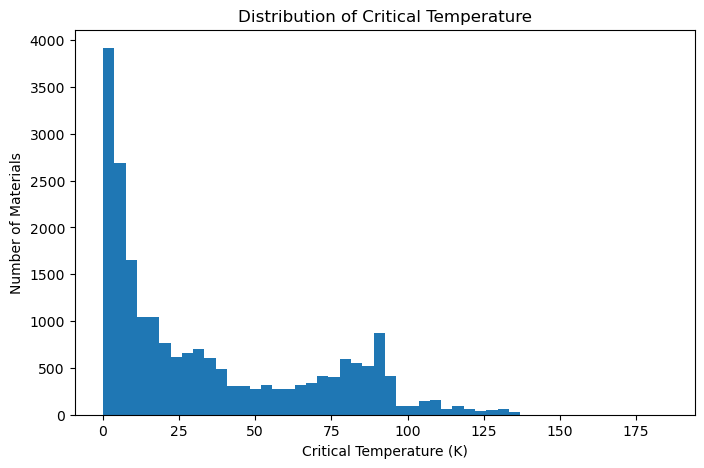

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["critical_temp"], bins=50)

plt.title("Distribution of Critical Temperature")

plt.xlabel("Critical Temperature (K)")

plt.ylabel("Number of Materials")
plt.savefig("../figures/critical_temperature_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
## This will show how superconducting materials are distributed according to their critical temperatures.

Interpretation: The distribution of critical temperature is positively skewed. Most superconducting materials exhibit relatively low critical temperatures (<20 K), while only a small fraction have high critical temperatures (>100 K). This imbalance should be considered during model evaluation.

#### Relationship between features and target

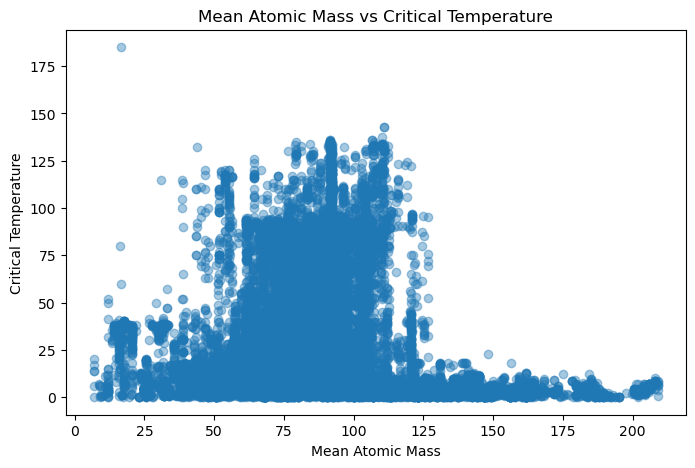

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["mean_atomic_mass"],
            df["critical_temp"],
            alpha=0.4)

plt.xlabel("Mean Atomic Mass")

plt.ylabel("Critical Temperature")

plt.title("Mean Atomic Mass vs Critical Temperature")
plt.savefig("../figures/atomic_mass_vs_tc.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
## This is a simple scatter plot that helps us see whether heavier materials tend to have different critical temperatures.

Interpretation: The scatter plot indicates that mean atomic mass alone is not a strong predictor of critical temperature. The wide distribution of data points suggests a weak linear correlation, highlighting the need for machine learning models that can learn from multiple material features simultaneously.

### 5. Data Preprocessing

Before training machine learning models, the dataset is prepared by separating the input features from the target variable and splitting the data into training and testing sets. This ensures that model performance is evaluated on previously unseen data.

#### Feature and Target Separation

The input features (X) are separated from the target variable (critical temperature, Tc), which will be predicted by the machine learning models.

In [17]:
X, y = split_features_target(df, "critical_temp")

In [18]:
print("Features shape :", X.shape)
print("Target shape :", y.shape)

Features shape : (21263, 81)
Target shape : (21263,)


#### Train-Test Split

The dataset is divided into training and testing subsets. The training set is used to build the models, while the testing set is reserved for evaluating their predictive performance.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#### Training and Testing Dataset Sizes

The dimensions of the training and testing datasets are verified to ensure that the data has been split correctly.

In [20]:
print("Training data :", X_train.shape)
print("Testing data :", X_test.shape)

Training data : (17010, 81)
Testing data : (4253, 81)


### 6. Model Training

Four regression models are developed and evaluated to predict the superconducting critical temperature (Tc). The performance of each model is compared using standard regression metrics, and the best-performing model is selected for explainability analysis.

#### 6.1 Linear Regression

Linear Regression is used as the baseline model. It assumes a linear relationship between the input features and the target variable, providing a reference for comparing more advanced machine learning models.

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model = LinearRegression()

In [23]:
model.fit(X_train, y_train)

LinearRegression()

##### Model Prediction

The trained Linear Regression model is used to predict the critical temperature of the test dataset.

In [24]:
y_pred = model.predict(X_test)

In [25]:
print("Actual values")
print(y_test.head(10))

print("\nPredicted values")
print(y_pred[:10])

Actual values
13976     6.40
1710     91.20
369      38.00
1698     19.00
13540    11.00
7405     62.00
7363     84.00
4269     50.10
3211     35.00
8957      8.02
Name: critical_temp, dtype: float64

Predicted values
[ 4.02112777 78.79022379 59.00244334 28.45591439  6.51728226 64.13549839
 61.67811696 71.73378071 31.51535521 19.20469372]


##### Performance Evaluation

Model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 13.210522050794003
Mean Squared Error (MSE): 302.0075125501324
Root Mean Squared Error (RMSE): 17.378363344979654
R² Score: 0.7376312737138966


##### Linear Regression Results

The Linear Regression model achieved an R² score of **0.738**, indicating that approximately **73.8%** of the variation in the critical temperature can be explained by the input material descriptors.

The Mean Absolute Error (MAE) was **13.21 K**, meaning that the model's predictions differed from the actual critical temperature by an average of about **13 Kelvin**.

The Root Mean Squared Error (RMSE) was **17.38 K**, which is higher than the MAE, indicating that the model makes some relatively large prediction errors for certain superconducting materials.

Overall, Linear Regression provides a good baseline model; however, the complex nonlinear relationships between material properties and superconducting critical temperature suggest that more advanced machine learning models may achieve better predictive performance.

##### Actual vs Predicted Values

A scatter plot compares the predicted critical temperatures with the actual values to visually assess prediction accuracy.

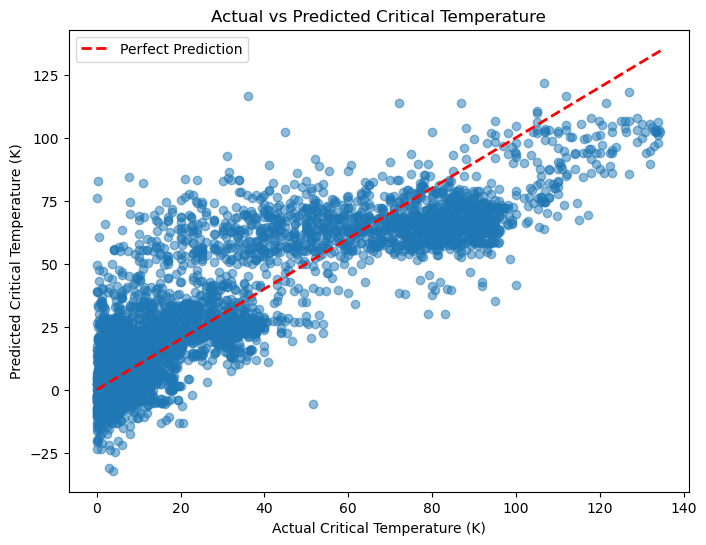

In [27]:
## actual vs predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Critical Temperature (K)")
plt.ylabel("Predicted Critical Temperature (K)")
plt.title("Actual vs Predicted Critical Temperature")
plt.legend()
plt.savefig("../figures/actual_vs_predicted.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

#### 6.2 Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive accuracy and reduce overfitting.

##### Model Training

The Random Forest model is trained using the training dataset with predefined hyperparameters.

In [28]:
rf_model = train_random_forest(
    X_train,
    y_train,
    n_estimators=30,
    random_state=42
)

##### Model Prediction

The trained Random Forest model is used to predict the critical temperature for the testing dataset.

In [29]:
rf_results = evaluate_model(rf_model, X_test, y_test)

print_results("Random Forest", rf_results)


Random Forest
-------------
MAE : 5.1621
RMSE: 9.1423
R²  : 0.9274


##### Performance Evaluation

The predictive performance of the Random Forest model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).
These metrics measure the prediction accuracy of the model and allow comparison with the Linear Regression baseline.

In [30]:
rf_results = evaluate_model(rf_model, X_test, y_test)

print_results("Random Forest", rf_results)


Random Forest
-------------
MAE : 5.1621
RMSE: 9.1423
R²  : 0.9274


In [31]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_results["MAE"]],
    "RMSE": [rmse, rf_results["RMSE"]],
    "R2 Score": [r2, rf_results["R2"]]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,13.210522,17.378363,0.737631
1,Random Forest,5.162105,9.142324,0.927388


##### Feature Importance

Feature importance scores are computed to identify the material descriptors that contribute most significantly to the Random Forest model's predictions.

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
67,range_ThermalConductivity,0.535638
64,wtd_gmean_ThermalConductivity,0.126368
9,std_atomic_mass,0.026436
74,wtd_gmean_Valence,0.020827
66,wtd_entropy_ThermalConductivity,0.011472
31,mean_Density,0.011246
80,wtd_std_Valence,0.010446
43,gmean_ElectronAffinity,0.010412
72,wtd_mean_Valence,0.010054
62,wtd_mean_ThermalConductivity,0.009862


##### Feature Importance Visualization

A bar chart is used to visualize the relative importance of the most influential features identified by the Random Forest model.

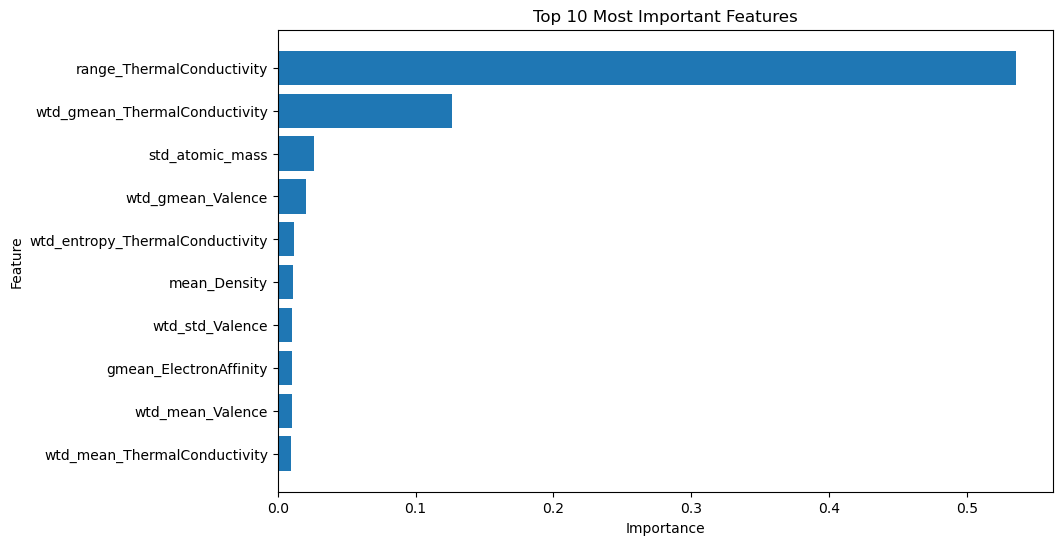

In [33]:
top10 = importance.head(10)

## Feature Importance Visualization
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()
plt.savefig("../figures/feature_importance.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

##### Feature Importance Interpretation

Feature importance analysis was performed using the Random Forest Regressor to identify the material descriptors that contribute most significantly to predicting the superconducting critical temperature (Tc).

The analysis revealed that a small subset of features has a much greater influence on the model's predictions than the remaining variables. This indicates that superconducting behavior is governed by the combined effects of multiple physical and chemical properties rather than by a single material descriptor.

The feature importance results also demonstrate one of the major advantages of tree-based machine learning models: besides providing accurate predictions, they help identify the most influential variables in complex materials datasets. Such insights can assist researchers in understanding which material characteristics should be prioritized when designing or discovering new superconducting materials.

##### Cross Validation

Cross-validation is performed to evaluate the robustness and generalization ability of the Random Forest model across multiple data splits.

In [34]:
from sklearn.model_selection import cross_val_score

In [35]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [36]:
print("Cross Validation R² Scores")

print(cv_scores)

Cross Validation R² Scores
[0.70904732 0.68991189 0.87289947 0.78389388 0.63873398]


In [37]:
print("Average R² Score :", cv_scores.mean())

Average R² Score : 0.7388973089022844


In [38]:
print("Standard Deviation :", cv_scores.std())

Standard Deviation : 0.08161440692069417


##### Cross Validation Discussion

To evaluate the robustness and generalization ability of the Random Forest model, 5-fold cross-validation was performed using the R² score as the evaluation metric.

The average cross-validation R² score obtained was **0.739**, which is very close to the R² score achieved on the independent test set. This indicates that the model performs consistently on different subsets of the dataset and is not overly dependent on a particular train-test split.

The standard deviation of **0.082** suggests moderate variability across the folds, indicating reasonable model stability while also highlighting opportunities for further improvement through hyperparameter tuning.

#### 6.3 Hyperparameter Tuning

Randomized Search Cross-Validation is employed to optimize the hyperparameters of the Random Forest model. The optimal parameter values identified during the search are displayed below, followed by the performance evaluation of the tuned model using MAE, RMSE, and R² score. This comparison demonstrates the impact of hyperparameter optimization on predictive performance.

In [39]:
RandomForestRegressor(
    n_estimators=30
)

RandomForestRegressor(n_estimators=30)

In [40]:
## Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [30, 50],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [41]:
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=4,   # only 4 combinations
    cv=3,     # only 2-fold CV
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

In [42]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [30, 50]},
                   random_state=42, scoring='r2')

In [43]:
print("Best Parameters:")
print(random_search.best_params_)

print("Best Cross Validation Score:")
print(random_search.best_score_)

best_rf = random_search.best_estimator_

best_rf_results = evaluate_model(best_rf, X_test, y_test)

print_results("Tuned Random Forest", best_rf_results)

Best Parameters:
{'n_estimators': 30, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Best Cross Validation Score:
0.9101045572341033

Tuned Random Forest
-------------------
MAE : 5.1732
RMSE: 9.0468
R²  : 0.9289


In [44]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        rf_results["MAE"],
        best_rf_results["MAE"]
    ],
    "RMSE": [
        rmse,
        rf_results["RMSE"],
        best_rf_results["RMSE"]
    ],
    "R² Score": [
        r2,
        rf_results["R2"],
        best_rf_results["R2"]
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,13.210522,17.378363,0.737631
1,Random Forest,5.162105,9.142324,0.927388
2,Tuned Random Forest,5.173197,9.046832,0.928897


##### Hyperparameter Tuning Discussion

Hyperparameter tuning was performed using RandomizedSearchCV to optimize the Random Forest model. Different combinations of model parameters were evaluated using cross-validation to identify the configuration that achieved the best predictive performance.

The tuned Random Forest model achieved an R² score of approximately 0.929, representing a slight improvement over the baseline Random Forest model (R² = 0.927). Although the improvement was modest, the optimization process confirmed that the selected hyperparameters enhanced the model's predictive accuracy while maintaining good generalization performance.

These results demonstrate the importance of systematic hyperparameter optimization in developing robust machine learning models for materials science applications.

In [45]:
import os
print(os.getcwd())

d:\Projects\Predict-Physical-Quantities-Using-Machine-Learning\notebooks


In [46]:
import os

print(os.path.exists("../models"))

True


In [47]:
import joblib

joblib.dump(best_rf, "../models/random_forest_superconductor.pkl")

['../models/random_forest_superconductor.pkl']

#### Residual Analysis

The residuals of the optimized Random Forest model are analyzed to evaluate prediction errors and identify any systematic patterns.

In [48]:
best_pred = best_rf.predict(X_test)

residuals = y_test - best_pred

residuals.head()

13976   -4.889503
1710     6.717603
369      9.523648
1698     1.506684
13540    0.380875
Name: critical_temp, dtype: float64

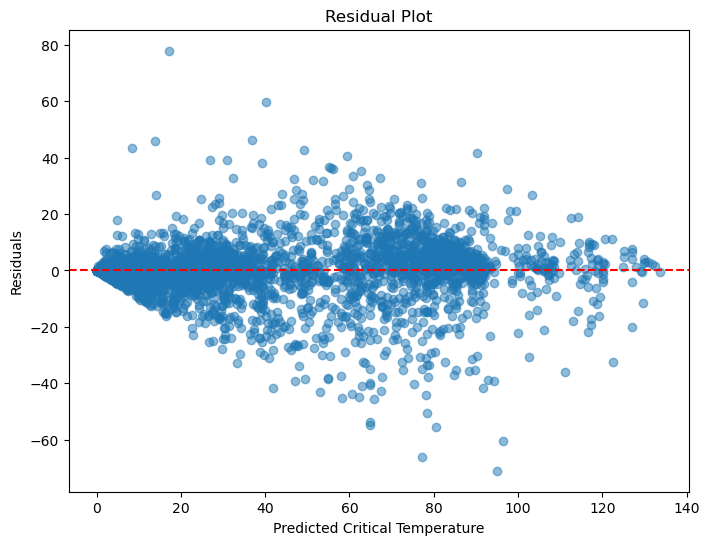

In [49]:
## Scatter Plot of Residuals
plt.figure(figsize=(8,6))

plt.scatter(best_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Critical Temperature")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("../figures/residual_plot.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

##### Residual Distribution

The distribution of residuals is visualized to assess the prediction errors and identify any potential bias in the model.

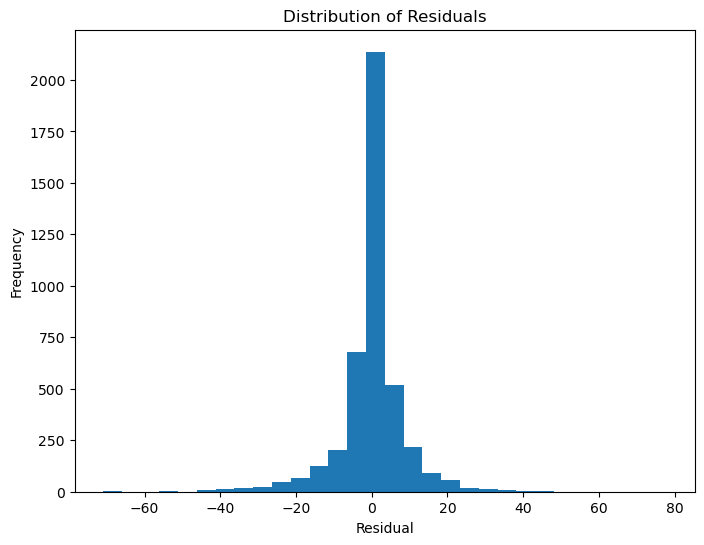

In [50]:
## Histogram of Residuals
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.savefig("../figures/residual_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [51]:
## Residual Statistics
print("Mean Residual :", residuals.mean())
print("Standard Deviation :", residuals.std())
print("Minimum Residual :", residuals.min())
print("Maximum Residual :", residuals.max())

Mean Residual : -0.1266280454347745
Standard Deviation : 9.047009226641801
Minimum Residual : -71.0083082010582
Maximum Residual : 77.90688794208955


##### Residual Analysis Discussion

Residual analysis was performed to assess the prediction errors of the tuned Random Forest model.

The mean residual was approximately **−0.13**, which is very close to zero, indicating that the model does not exhibit a significant systematic bias toward overestimation or underestimation.

The residual standard deviation was approximately **9.05 K**, consistent with the model's RMSE, indicating stable prediction errors across the test dataset.

Although a small number of samples exhibited relatively large residuals, these are likely associated with materials possessing complex or uncommon physical characteristics that are more difficult to model accurately.

Overall, the residual analysis supports the conclusion that the tuned Random Forest model provides reliable predictions for superconducting critical temperature while maintaining good generalization performance.

#### 6.4 XGBoost Regression

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting. It builds decision trees sequentially to improve prediction accuracy and effectively captures complex nonlinear relationships within the data.

In [52]:
import sys
print(sys.executable)

c:\Users\mona2\anaconda3\python.exe


In [53]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [54]:
from xgboost import XGBRegressor
print("XGBoost installed successfully!")

XGBoost installed successfully!


In [55]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

##### Model Training

The XGBoost regression model is trained using the training dataset to learn the relationship between the material descriptors and the superconducting critical temperature (Tc).

In [56]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

##### Model Prediction

The trained XGBoost model is used to predict the critical temperature for the testing dataset.

In [57]:
y_pred_xgb = xgb_model.predict(X_test)

##### Performance Evaluation

The predictive performance of the XGBoost model is evaluated using MAE, RMSE, and R² score. These metrics are later compared with the other regression models.

In [58]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 5.8431
RMSE: 9.3378
R²  : 0.9242


### 7. Model Comparison

The performance of all regression models is compared using standard evaluation metrics. This comparison identifies the most accurate model for predicting the superconducting critical temperature.

In [59]:
## Linear Regression
import joblib

joblib.dump(
    model,
    "../models/linear_regression_superconductor.pkl"
)

print("✅ Linear Regression model saved.")

✅ Linear Regression model saved.


In [60]:
## Linear Regression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred_lr = model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print(f"MAE : {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R²  : {lr_r2:.4f}")

Linear Regression
MAE : 13.2105
RMSE: 17.3784
R²  : 0.7376


In [61]:
## RandomForest
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest
MAE : 5.1621
RMSE: 9.1423
R²  : 0.9274


In [62]:
## Tuned Random Forest
best_rf = random_search.best_estimator_

joblib.dump(
    best_rf,
    "../models/tuned_random_forest_superconductor.pkl"
)

print("✅ Tuned Random Forest model saved.")

✅ Tuned Random Forest model saved.


In [63]:
## Tuned Random Forest
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = root_mean_squared_error(y_test, y_pred_tuned)
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print(f"MAE : {tuned_mae:.4f}")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"R²  : {tuned_r2:.4f}")

Tuned Random Forest
MAE : 5.1732
RMSE: 9.0468
R²  : 0.9289


In [64]:
## XGBoost model
joblib.dump(
    xgb_model,
    "../models/xgboost_superconductor.pkl"
)

print("✅ XGBoost model saved.")

✅ XGBoost model saved.


#### Model Performance Comparison

The performance of the four regression models is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). These metrics are used to identify the model that provides the most accurate predictions of the superconducting critical temperature (Tc).

The table below summarizes the performance of all evaluated models.

#### Performance Comparison Table

The table below summarizes the performance of all machine learning models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

In [65]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "MAE": [
        13.2105,
        5.1621,
        5.1732,
        5.8431
    ],
    "RMSE": [
        17.3784,
        9.1423,
        9.0468,
        9.3378
    ],
    "R² Score": [
        0.7376,
        0.9274,
        0.9289,
        0.9242
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,13.2105,17.3784,0.7376
1,Random Forest,5.1621,9.1423,0.9274
2,Tuned Random Forest,5.1732,9.0468,0.9289
3,XGBoost,5.8431,9.3378,0.9242


#### Model Performance Visualization

A bar chart is used to visually compare the predictive performance of all machine learning models based on their R² scores. Higher R² values indicate better predictive accuracy.

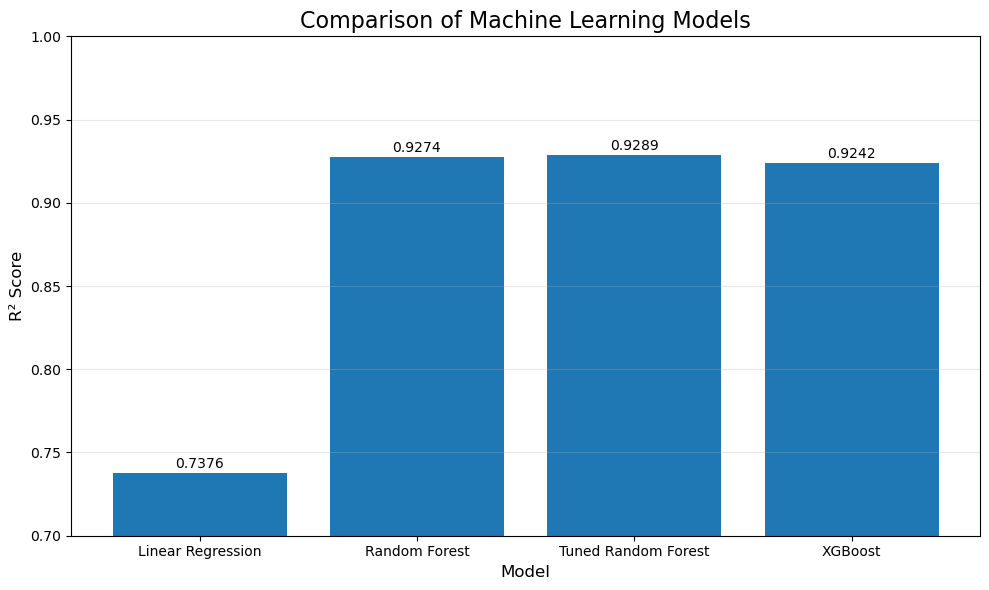

In [66]:
## Comparison Graph
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

bars = plt.bar(results["Model"], results["R² Score"])

plt.title("Comparison of Machine Learning Models", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0.70,1.00)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.003,
        f"{y:.4f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

Among all evaluated models, the Tuned Random Forest achieved the highest predictive performance, with the highest R² score and the lowest RMSE. Although XGBoost also demonstrated strong performance, the optimized Random Forest model provided the most accurate predictions for the superconducting critical temperature dataset. Therefore, the Tuned Random Forest model was selected for the subsequent explainability analysis.

In [67]:
import os

os.makedirs("../results", exist_ok=True)

results.to_csv(
    "../results/model_performance.csv",
    index=False
)

print("✅ Results saved.")

✅ Results saved.


### 8. Model Explainability (SHAP)

To improve the interpretability of the best-performing model, SHAP (SHapley Additive exPlanations) is used. SHAP quantifies the contribution of each feature to the predicted superconducting critical temperature (Tc), helping identify the most influential material descriptors and providing insights into the model's decision-making process.

In [68]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [69]:
import shap

#### SHAP Value Computation

SHAP values are computed for the optimized Random Forest model to explain the contribution of each feature to the model's predictions.

In [70]:
## Compute SHAP Values
explainer, shap_values = compute_shap_values(best_rf, X_test)

#### SHAP Summary Plot

The SHAP summary plot visualizes both the importance and the direction of influence of each feature on the model's predictions across all samples.

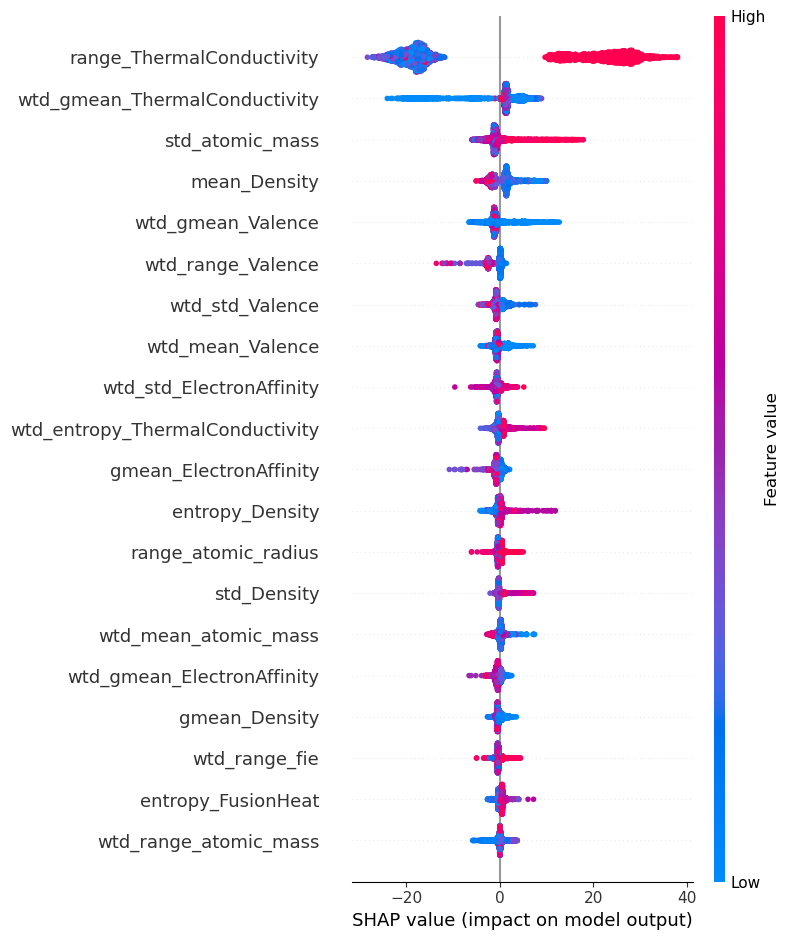

In [71]:
## summary plot:SHAP figure
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show() 

##This plot answers-
##Which features matter most?
## Whether high or low values of each feature increase or decrease the predicted Tc.

#### SHAP Feature Importance

The SHAP feature importance plot provides a global ranking of features based on their average contribution to the model's predictions.

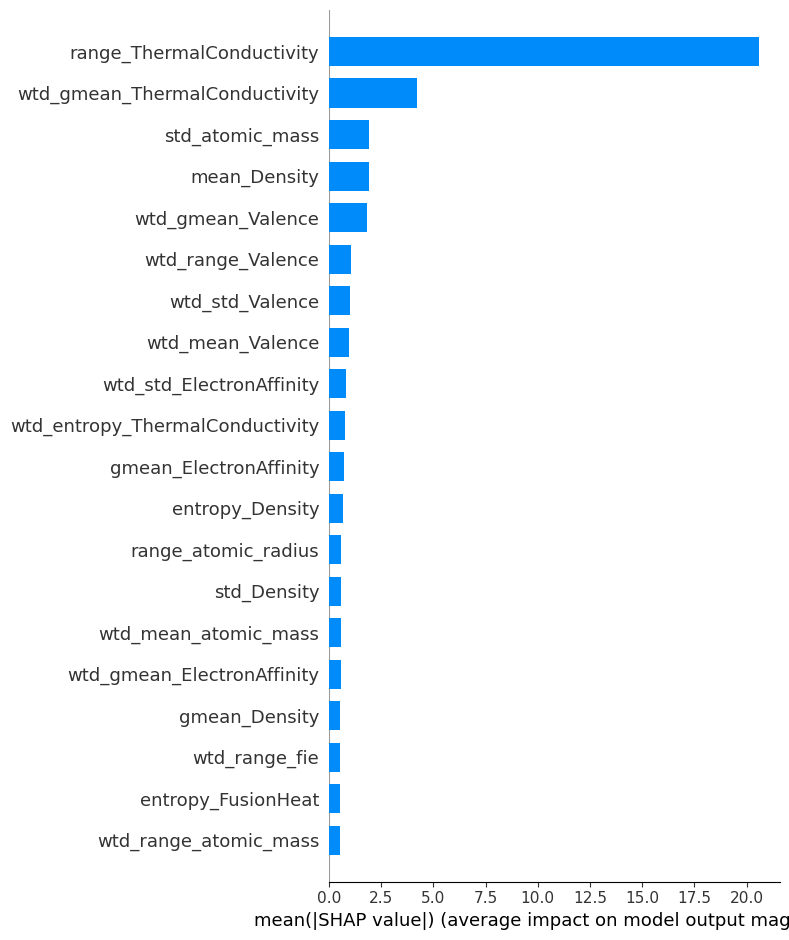

In [72]:
## bar plot
plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../figures/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()  ## gives a global ranking of feautre importance.

#### Interpretation

The SHAP analysis reveals that thermal conductivity, atomic mass, density, and valence-related descriptors are the most influential features in predicting the superconducting critical temperature (Tc). The SHAP summary plot illustrates both the magnitude and direction of each feature's impact on individual predictions, while the feature importance plot provides a global ranking based on average SHAP values. These findings improve the interpretability of the optimized Random Forest model and provide valuable insights into the material properties governing superconductivity.